# Local Variation + GNN iterative

## Import

In [1]:
import os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# pygsp
from pygsp import graphs

# scipy
import scipy as sp

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# torch geometric
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected

# sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# graph coarsening - Loukas 2020
from graphcoarsening.graph_coarsening.coarsening_utils import *
from graphcoarsening.graph_coarsening.graph_utils import *

# datasets
data_path = os.path.abspath(os.path.join("..", "data"))
if data_path not in sys.path:
    sys.path.append(data_path)
from cora.load_cora import load_cora_dataset

# plot
import matplotlib.pyplot as plt

# utils
from utils.split_dataset import *
from utils.visualization import *


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(1)
np.random.seed(1)


Using device: cuda


## Global data

- `NODE_IDS`: list of nodes ids
- `FEATURES`: (N x D) matrix of features for each node
- `LABELS`: (N) list of true labels for each node
- `EDGES_IDX`: (M, 2) matrix of edges
- `IDX_MAP`: dict mapping original node IDs to index

In [2]:
# load dataset and gloa
NODE_IDS, FEATURES, LABELS, EDGES_IDX, IDX_MAP = load_cora_dataset(log_info=False)
LABELS_ENCODED = LabelEncoder().fit_transform(LABELS)

## General functions

### Create PyGSP Graph

In [3]:
def create_pygsp_graph(edges, num_nodes) -> graphs.Graph: 
    # adjacency matrix
    adj_matrix = sp.sparse.coo_matrix(
        (np.ones(len(edges)),
        (edges[:, 0], edges[:, 1])), 
        shape=(num_nodes, num_nodes)
    )
    adj_matrix = adj_matrix + adj_matrix.T
    adj_matrix.data = np.ones(len(adj_matrix.data))

    # pygsp graph
    G = graphs.Graph(adj_matrix)
    G.compute_laplacian()
    G.set_coordinates()
    
    return G

### Apply coarsening by Loukas

In [8]:
def apply_graph_coarsening(G: graphs.Graph, X=None, method='variation_neighborhoods', ratio=0.5, K=3, log_info=False):
    """
    Output:
      - C: coarsening matrix (n, N)
      - Gc: coarsened graph (n, n)
      - Call: all coarsened graphs (levels, n_l, N)
      - Gall: all original graphs (levels, n_l, n_l)
    """
    
    available_methods = ['variation_neighborhoods', 'variation_edges', 'heavy_edge', 'algebraic_JC', 'kron'] 
    if method not in available_methods:
        raise ValueError(f"Unknown coarsening method: {method}. Method must be one of {available_methods}.")
    
    C, Gc, Call, Gall = coarsen(G, X=X, K=K, method=method, r=ratio)

    if log_info:
        print(f"Coarsening: {method} ", end='')
        print(f"({G.N} n, {G.Ne} e) -> ({Gc.N} n, {Gc.Ne} e); ")
    
    return C, Gc, Call, Gall

### Get coarsened data from Coarsening matrix C

In [5]:
def get_coarsened_edges_and_features(C: list, Gc: graphs.Graph, features):
    """
    Coarsen edges and features based on the coarsening matrix C;
    the feature matrix (N x D) is made by summing up features from nodes that are coarsened into the same supernode.

    Output:
      - Gc: coarsened edges index (num_edges, 2)
      - features_coarsened: coarsened features (num_nodes_coarsened, num_features)
    """

    idx_map = {} # map fine node -> coarse node 
    for supernode, node in zip(*C.nonzero()):
        idx_map[node] = supernode
        
    # features coarsened
    features_coarsened = C @ features
    
    # edges coarsened
    edges_idx_coarsened = np.array(Gc.get_edge_list()[:2]).T

    return edges_idx_coarsened, features_coarsened


def get_coarsened_edges_features_labels(C: list, Gc: graphs.Graph, features, labels, priority_label=0):
    """
    Coarsen edges and features based on the coarsening matrix C;
    the feature matrix (N x D) is made by summing up features from nodes that are coarsened into the same supernode.

    Output:
      - edges_idx_coarsened: coarsened edges index (num_edges, 2)
      - features_coarsened: coarsened features (num_nodes_coarsened, num_features)
      - labels_coarsened: coarsened labels (num_nodes_coarsened,)
    """

    idx_map = {} # map fine node -> coarse node 
    for supernode, node in zip(*C.nonzero()):
        idx_map[node] = supernode
        
    # features coarsened
    features_coarsened = C @ features

    # edges coarsened
    edges_idx_coarsened = np.array(Gc.get_edge_list()[:2]).T

    # labels coarsened
    num_classes = len(np.unique(labels))
    all_labels = np.zeros((C.shape[0], num_classes), dtype=np.float32)
    for supernode, node in zip(*C.nonzero()):
        all_labels[supernode, labels[node]] += 1

    labels_coarsened = np.zeros(C.shape[0], dtype=np.int64)
    for supernode in range(C.shape[0]):
        mx = np.argmax(all_labels[supernode])
        priority_count = all_labels[supernode, priority_label]
        if priority_count >= mx:
            labels_coarsened[supernode] = priority_label
        else: 
            labels_coarsened[supernode] = mx

    return edges_idx_coarsened, features_coarsened, labels_coarsened

## GNN

### model and training function

In [6]:
class GCN(nn.Module):
    def __init__(self, nfeat, nhid, nclass, dropout=.5):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(nfeat, nhid)
        self.conv2 = GCNConv(nhid, nclass)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)
    
    def get_embeddings(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return x

In [7]:
def create_pyg_data(features, edges_idx, labels) -> Data:
    x = torch.FloatTensor(features.astype(np.float32))
    y = torch.LongTensor(labels)
    edge_index = torch.LongTensor(edges_idx.T)  # expects (2, num_edges)
    edge_index = to_undirected(edge_index)
        
    return Data(x=x, edge_index=edge_index, y=y)

def train_gnn(model: nn.Module, optimizer: optim.Optimizer, data: Data, train_idx: list, val_idx: list, epochs=200, log_info=True):
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    data = data.to(next(model.parameters()).device)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        output = model(data.x, data.edge_index)

        # train
        loss_train = F.nll_loss(output[train_idx], data.y[train_idx])
        loss_train.backward()
        optimizer.step()
        
        # validate
        model.eval()
        with torch.no_grad():
            output = model(data.x, data.edge_index)
            loss_val = F.nll_loss(output[val_idx], data.y[val_idx])
            pred_val = output[val_idx].max(1)[1]
            acc_val = accuracy_score(data.y[val_idx].cpu().numpy(), pred_val.cpu().numpy())
        
        # save data
        train_losses.append(loss_train.item())
        val_losses.append(loss_val.item())
        val_accuracies.append(acc_val)
        
        # log info
        if epoch % 10 == 0 and log_info:
            print(f'Epoch {epoch:03d}, Train Loss: {loss_train:.4f}, '
                  f'Val Loss: {loss_val:.4f}, Val Acc: {acc_val:.4f}')
    
    return train_losses, val_losses, val_accuracies

def evaluate_model(model: nn.Module, data: Data, test_idx, log_info=True):
    """Evaluate the model on test set."""
    model.eval()
    data = data.to(next(model.parameters()).device)
    
    with torch.no_grad():
        output = model(data.x, data.edge_index)
        pred_test = output[test_idx].max(1)[1]
        acc_test = accuracy_score(data.y[test_idx].cpu().numpy(), pred_test.cpu().numpy())
        
        if log_info:
            print(f'\nTest Accuracy: {acc_test:.4f}')
            print('\nClassification Report:')
            print(classification_report(
                data.y[test_idx].cpu().numpy(), pred_test.cpu().numpy())
            )

    return acc_test, pred_test

## `Coarsen - GNN` iteration

Coarsening: variation_neighborhoods (2708 n, 5278 e) -> (549 n, 813 e); 
Iteration 01/100, coarse accuracy: 0.7477, fine accuracy: 0.7520

Coarsening: variation_neighborhoods (2708 n, 5278 e) -> (543 n, 855 e); 
Iteration 02/100, coarse accuracy: 0.6455, fine accuracy: 0.3729

Coarsening: variation_neighborhoods (2708 n, 5278 e) -> (545 n, 865 e); 
Iteration 03/100, coarse accuracy: 0.7248, fine accuracy: 0.8328

Coarsening: variation_neighborhoods (2708 n, 5278 e) -> (556 n, 754 e); 
Iteration 04/100, coarse accuracy: 0.7232, fine accuracy: 0.3330

Coarsening: variation_neighborhoods (2708 n, 5278 e) -> (545 n, 810 e); 
Iteration 05/100, coarse accuracy: 0.8165, fine accuracy: 0.3130

Coarsening: variation_neighborhoods (2708 n, 5278 e) -> (543 n, 843 e); 
Iteration 06/100, coarse accuracy: 0.7182, fine accuracy: 0.2634

Coarsening: variation_neighborhoods (2708 n, 5278 e) -> (545 n, 967 e); 
Iteration 07/100, coarse accuracy: 0.7156, fine accuracy: 0.4060

Coarsening: variation_neigh

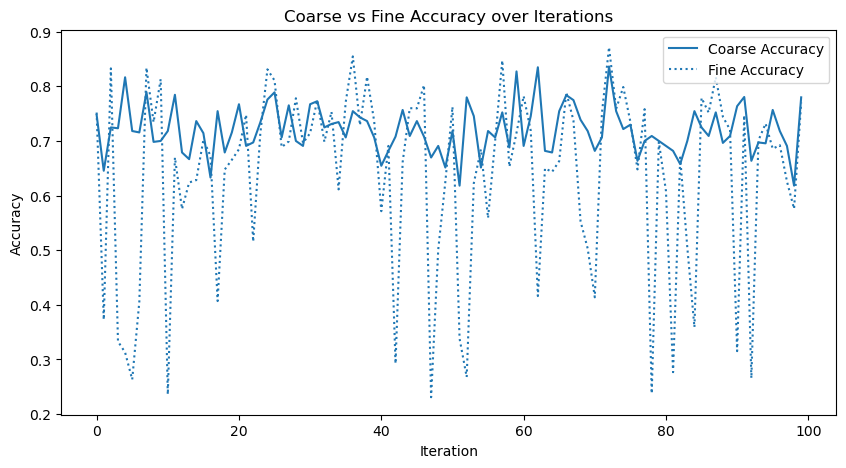

In [ ]:
# model
nfeat = FEATURES.shape[1]  # 1433
nhid = 128
nclass = len(np.unique(LABELS_ENCODED))  # 7
dropout = 0.1
model = GCN(nfeat=nfeat, nhid=nhid, nclass=nclass, dropout=dropout).to(device)

# train data
wd = 5e-4
lr = 0.003
epochs = 500
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

# initialize the GNN to produce first embeddings
data = create_pyg_data(FEATURES, EDGES_IDX, LABELS_ENCODED)
train_idx, val_idx, test_idx = create_train_val_test_split(data.num_nodes)
train_idx = torch.LongTensor(train_idx).to(device)
val_idx = torch.LongTensor(val_idx).to(device)
test_idx = torch.LongTensor(test_idx).to(device)
t_losses, v_losses, v_accuracies = train_gnn(
    model, optimizer, data, train_idx, val_idx, epochs=epochs, log_info=False
)

max_iter = 100
x = [i for i in range(max_iter)]
ycrs = []
yfine = []
for iterate in range(max_iter):

    # get embeddings from the GNN
    embeddings = model.get_embeddings(data.x, data.edge_index)
    embeddings = embeddings.cpu().detach().numpy()

    # coarsen the graph using embeddings as features
    G = create_pygsp_graph(EDGES_IDX, data.num_nodes)
    C, Gc, Call, Gall = apply_graph_coarsening(
        G, X=embeddings, method='variation_neighborhoods', ratio=0.8, K=50, log_info=True
    )

    # train the GNN on the coarsened graph
    edges_idx_c, feat_c, labels_C = get_coarsened_edges_features_labels(
        C, Gc, FEATURES, LABELS_ENCODED, priority_label=0
    )
    data_c = create_pyg_data(feat_c, edges_idx_c, labels_C)
    train_idx_c, val_idx_c, test_idx_c = create_train_val_test_split(data_c.num_nodes)
    train_idx_c = torch.LongTensor(train_idx_c).to(device)
    val_idx_c = torch.LongTensor(val_idx_c).to(device)
    test_idx_c = torch.LongTensor(test_idx_c).to(device)
    t_losses_c, v_losses_c, v_accuracies_c = train_gnn(
        model, optimizer, data_c, train_idx_c, val_idx_c, epochs=epochs, log_info=False
    )
    
    # evaluate the model on the coarsened graph
    acc_test_c, pred_test_c = evaluate_model(model, data_c, test_idx_c, log_info=False)

    # evaluate on original (fine) graph
    pred_fine = np.array([-1 for _ in range(NODE_IDS.shape[0])], dtype=np.int64)
    tot = 0
    for idx in range(len(test_idx_c)):
        test_supernode = test_idx_c[idx]
        for fine_node in C.getrow(test_supernode).nonzero()[1]:
            pred_fine[fine_node] = pred_test_c[idx]
            tot += 1

    sm = sum(pred_fine == LABELS_ENCODED)
    accuracy_fine = sm / tot

    print(f"Iteration {iterate + 1:02d}/{max_iter}, coarse accuracy: {acc_test_c:.4f}, fine accuracy: {accuracy_fine:.4f}\n")

    # ploting data
    ycrs.append(acc_test_c)
    yfine.append(accuracy_fine)


# plot the results
plt.figure(figsize=(10, 5))
plt.plot(x, ycrs, label='Coarse Accuracy', color='tab:blue')
plt.plot(x, yfine, label='Fine Accuracy', linestyle=':', color='tab:blue')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Coarse vs Fine Accuracy over Iterations')
plt.show()